## 🦠 Covid-19 Tweet Sentiment Prediction

Given *tweets about the COVID=19 pandemic*, let's try to predict the **sentiment** of a given tweet.

We will use a TensorFlow RNN to make our predictions.

Data source: https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification/

### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px

import re
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf

In [4]:
train_df = pd.read_csv('archive/Corona_NLP_train.csv', encoding='latin-1')
test_df = pd.read_csv('archive/Corona_NLP_test.csv', encoding='latin-1')

In [5]:
train_df

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
...,...,...,...,...,...,...
41152,44951,89903,"Wellington City, New Zealand",14-04-2020,Airline pilots offering to stock supermarket s...,Neutral
41153,44952,89904,NaN,14-04-2020,Response to complaint not provided citing COVI...,Extremely Negative
41154,44953,89905,NaN,14-04-2020,You know itÂs getting tough when @KameronWild...,Positive
41155,44954,89906,NaN,14-04-2020,Is it wrong that the smell of hand sanitizer i...,Neutral


In [6]:
test_df

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral
...,...,...,...,...,...,...
3793,3794,48746,Israel ??,16-03-2020,Meanwhile In A Supermarket in Israel -- People...,Positive
3794,3795,48747,"Farmington, NM",16-03-2020,Did you panic buy a lot of non-perishable item...,Negative
3795,3796,48748,"Haverford, PA",16-03-2020,Asst Prof of Economics @cconces was on @NBCPhi...,Neutral
3796,3797,48749,NaN,16-03-2020,Gov need to do somethings instead of biar je r...,Extremely Negative


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   UserName       41157 non-null  int64
 1   ScreenName     41157 non-null  int64
 2   Location       32567 non-null  str  
 3   TweetAt        41157 non-null  str  
 4   OriginalTweet  41157 non-null  str  
 5   Sentiment      41157 non-null  str  
dtypes: int64(2), str(4)
memory usage: 1.9 MB


In [8]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   UserName       3798 non-null   int64
 1   ScreenName     3798 non-null   int64
 2   Location       2964 non-null   str  
 3   TweetAt        3798 non-null   str  
 4   OriginalTweet  3798 non-null   str  
 5   Sentiment      3798 non-null   str  
dtypes: int64(2), str(4)
memory usage: 178.2 KB


### Preprocessing

In [12]:
train_inputs = train_df['OriginalTweet'].copy()
test_inputs = test_df['OriginalTweet'].copy()

train_labels = train_df['Sentiment'].copy()
test_labels = test_df['Sentiment'].copy()

In [13]:
train_inputs

0        @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...
1        advice Talk to your neighbours family to excha...
2        Coronavirus Australia: Woolworths to give elde...
3        My food stock is not the only one which is emp...
4        Me, ready to go at supermarket during the #COV...
                               ...                        
41152    Airline pilots offering to stock supermarket s...
41153    Response to complaint not provided citing COVI...
41154    You know itÂs getting tough when @KameronWild...
41155    Is it wrong that the smell of hand sanitizer i...
41156    @TartiiCat Well new/used Rift S are going for ...
Name: OriginalTweet, Length: 41157, dtype: str

In [14]:
train_labels

0                   Neutral
1                  Positive
2                  Positive
3                  Positive
4        Extremely Negative
                ...        
41152               Neutral
41153    Extremely Negative
41154              Positive
41155               Neutral
41156              Negative
Name: Sentiment, Length: 41157, dtype: str

In [15]:
train_labels.unique()

<StringArray>
['Neutral', 'Positive', 'Extremely Negative', 'Negative',
 'Extremely Positive']
Length: 5, dtype: str

In [51]:
sentiment_encoding = {
    'Extremely Negative': 0,
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2,
    'Extremely Positive': 2
}

train_labels = train_labels.replace(sentiment_encoding).astype(int)
test_labels = test_labels.replace(sentiment_encoding).astype(int)

In [52]:
train_labels

0        1
1        2
2        2
3        2
4        0
        ..
41152    1
41153    0
41154    2
41155    1
41156    0
Name: Sentiment, Length: 41157, dtype: int64

In [18]:
train_inputs

0        @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...
1        advice Talk to your neighbours family to excha...
2        Coronavirus Australia: Woolworths to give elde...
3        My food stock is not the only one which is emp...
4        Me, ready to go at supermarket during the #COV...
                               ...                        
41152    Airline pilots offering to stock supermarket s...
41153    Response to complaint not provided citing COVI...
41154    You know itÂs getting tough when @KameronWild...
41155    Is it wrong that the smell of hand sanitizer i...
41156    @TartiiCat Well new/used Rift S are going for ...
Name: OriginalTweet, Length: 41157, dtype: str

In [28]:
stop_words = stopwords.words('english')

def process_tweet(tweet):
    tweet = re.sub(r'http\S+', ' ', tweet) # remove urls
    tweet = re.sub(r'<.*?>', ' ', tweet) # remove html tags
    tweet = re.sub(r'\d+', ' ', tweet) # remove digits
    tweet = re.sub(r'#\w+', ' ', tweet) # remove hashtags
    tweet = re.sub(r'@\w+', ' ', tweet) # remove mentions
    tweet = tweet.split()
    tweet = " ".join([word for word in tweet if not word in stop_words])
    return tweet

In [29]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [31]:
train_inputs = train_inputs.apply(process_tweet)
test_inputs = test_inputs.apply(process_tweet)

In [32]:
train_inputs

0                                                         
1        advice Talk neighbours family exchange phone n...
2        Coronavirus Australia: Woolworths give elderly...
3        My food stock one empty... PLEASE, panic, THER...
4        Me, ready go supermarket outbreak. Not I'm par...
                               ...                        
41152    Airline pilots offering stock supermarket shel...
41153    Response complaint provided citing COVID- rela...
41154    You know itÂs getting tough rationing toilet ...
41155      Is wrong smell hand sanitizer starting turn on?
41156    Well new/used Rift S going $ . Amazon rn altho...
Name: OriginalTweet, Length: 41157, dtype: str

In [33]:
max_seq_len = np.max(train_inputs.apply(lambda tweet: len(tweet)))

In [34]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_inputs)

tokenizer.word_index

{'covid': 1,
 'i': 2,
 'prices': 3,
 'store': 4,
 'food': 5,
 'supermarket': 6,
 'grocery': 7,
 'people': 8,
 'amp': 9,
 'the': 10,
 'consumer': 11,
 'shopping': 12,
 'online': 13,
 'get': 14,
 'pandemic': 15,
 'need': 16,
 'workers': 17,
 'panic': 18,
 'us': 19,
 'like': 20,
 'time': 21,
 'home': 22,
 'go': 23,
 'demand': 24,
 'we': 25,
 'coronavirus': 26,
 'sanitizer': 27,
 'this': 28,
 'help': 29,
 'hand': 30,
 'stock': 31,
 'going': 32,
 'one': 33,
 'due': 34,
 'buying': 35,
 'new': 36,
 'please': 37,
 'you': 38,
 'in': 39,
 'work': 40,
 'crisis': 41,
 'if': 42,
 'it': 43,
 'oil': 44,
 'a': 45,
 'toilet': 46,
 'paper': 47,
 'stay': 48,
 'local': 49,
 'today': 50,
 'keep': 51,
 'buy': 52,
 'via': 53,
 'many': 54,
 'stores': 55,
 'shelves': 56,
 'still': 57,
 'make': 58,
 'see': 59,
 'now': 60,
 'delivery': 61,
 'know': 62,
 'day': 63,
 'take': 64,
 'to': 65,
 'outbreak': 66,
 'supply': 67,
 'would': 68,
 'retail': 69,
 'stop': 70,
 'staff': 71,
 'how': 72,
 'even': 73,
 'social': 74

In [36]:
vocab_length = len(tokenizer.word_index) + 1

In [37]:
train_inputs = tokenizer.texts_to_sequences(train_inputs)
test_inputs = tokenizer.texts_to_sequences(test_inputs)

In [38]:
print("Vocab Length:", vocab_length)
print("Maximum Sequence Length:", max_seq_len)

Vocab Length: 36114
Maximum Sequence Length: 286


In [39]:
train_inputs = pad_sequences(train_inputs, maxlen=max_seq_len, padding='post')
test_inputs = pad_sequences(test_inputs, maxlen=max_seq_len, padding='post')

In [40]:
train_inputs

array([[   0,    0,    0, ...,    0,    0,    0],
       [ 439,  818, 2517, ...,    0,    0,    0],
       [  26,  672, 4357, ...,    0,    0,    0],
       ...,
       [  38,   62,  135, ...,    0,    0,    0],
       [ 155,  647, 3932, ...,    0,    0,    0],
       [ 131,   36,  398, ...,    0,    0,    0]],
      shape=(41157, 286), dtype=int32)

In [53]:
test_inputs

array([[ 2794,    36,  5249, ...,     0,     0,     0],
       [  196,     2,   136, ...,     0,     0,     0],
       [  136,   223,  1668, ...,     0,     0,     0],
       ...,
       [ 4646,  3030,   898, ...,     0,     0,     0],
       [  847,    16, 16591, ...,     0,     0,     0],
       [    2,   737,  2378, ...,     0,     0,     0]],
      shape=(3798, 286), dtype=int32)

### Modeling

In [41]:
train_inputs.shape

(41157, 286)

In [54]:
embedding_dim = 16

inputs = tf.keras.Input(shape=(max_seq_len, ), name='input_layer')

embedding = tf.keras.layers.Embedding(
    input_dim = vocab_length,
    output_dim = embedding_dim,
    input_length = max_seq_len,
    name='word_embedding'
)(inputs)

gru_layer = tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(units=128, return_sequences=True, name='gru_layer'),
    name='bidirectional_layer'
)(embedding)

max_pooling = tf.keras.layers.GlobalMaxPool1D(name='max_pooling')(gru_layer)

dropout_1 = tf.keras.layers.Dropout(0.4, name='dropout_1')(max_pooling)

dense = tf.keras.layers.Dense(64, activation='relu', name='dense')(dropout_1)

dropout_2 = tf.keras.layers.Dropout(0.4, name='dropout_2')(dense)

outputs = tf.keras.layers.Dense(3, activation='softmax', name='output_layer')(dropout_2)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

print(model.summary())

# tf.keras.utils.plot_model(model)

D:\miniconda3\envs\tfenv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 286)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ word_embedding (Embedding)           │ (None, 286, 16)             │         577,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_layer (Bidirectional)  │ (None, 286, 256)            │         112,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling (GlobalMaxPooling1D)     │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 706,595 (2.70 MB)

 Trainable params: 706,595 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

None


### Training

In [55]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

batch_size = 32
epochs = 2

history = model.fit(
    train_inputs,
    train_labels,
    validation_split = 0.12,
    batch_size = batch_size,
    epochs = epochs
)

Epoch 1/2
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 420s 365ms/step - accuracy: 0.7388 - loss: 0.6253 - val_accuracy: 0.8528 - val_loss: 0.4129
Epoch 2/2
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 591s 497ms/step - accuracy: 0.8968 - loss: 0.3172 - val_accuracy: 0.8625 - val_loss: 0.3895


### Results

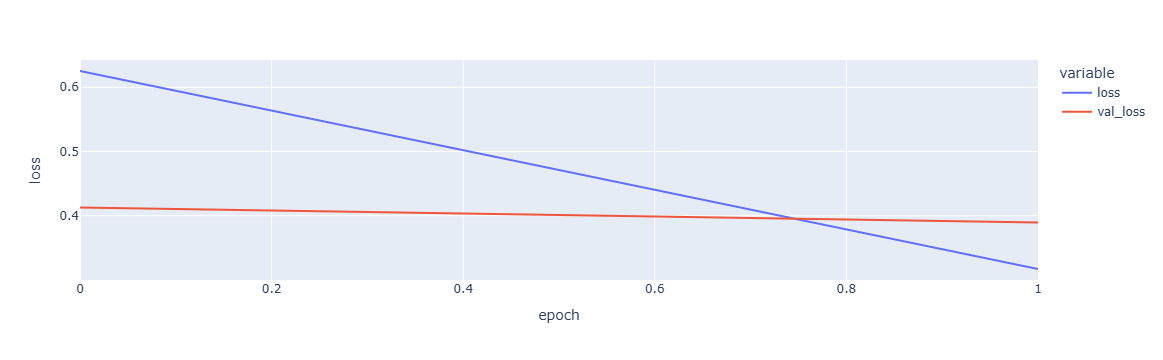

In [56]:
fig = px.line(
    history.history,
    y=['loss', 'val_loss'],
    labels={'index': 'epoch', 'value': 'loss'}
)
fig.show()

In [57]:
model.evaluate(test_inputs, test_labels)

119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.8404 - loss: 0.4554


[0.4554130733013153, 0.8404423594474792]